# 4c. Gradient Boosting

**Project:** Predicting colorectal cancer screening non-compliance to guide targeted outreach
**Part of:** the modelling stage, split one notebook per model (`4a`-`4d`) so each model's fit,
results, and interpretation can be read, run, and re-run independently. All four write into the
same shared model registry (`data/processed/modelling/model_registry_manifest.csv`); the
cross-model comparison lives in `5 Evaluation.ipynb`, which reads that shared manifest rather than
refitting anything itself. (previous: `4b (Random Forest)` | next: `4d (Feedforward Neural Network)`)

**Inputs:** `crc_analytic_dataset.csv` (Data Preparation output), the split/technique artifacts
validated in `3 Data Processing.ipynb`, and the shared preprocessing components in
`pipeline_components.py`.

This notebook covers the second tree ensemble and the proposal's leading ML model -- fit on M1/M2/M3, plus a cross-validated hyperparameter search. Every model notebook follows the same three-part structure --
**Model** (what's fit and how), **Results** (held-out test performance), **Analysis of factors**
(what's driving the predictions) -- so the four are easy to compare despite living in separate
files.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 100)

DATA_DIR = Path("../data")
PROCESSED_DIR = DATA_DIR / "processed"
MODEL_DIR = PROCESSED_DIR / "modelling"
FIGURES_DIR = Path("../figures")
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

ANALYTIC_PATH = PROCESSED_DIR / "crc_analytic_dataset.csv"
SPLIT_PATH = MODEL_DIR / "train_calibration_test_split.csv"
for p in [ANALYTIC_PATH, SPLIT_PATH]:
    if not p.exists():
        raise FileNotFoundError(f"{p} not found. Run '3 Data Processing.ipynb' first.")

df = pd.read_csv(
    ANALYTIC_PATH,
    dtype={"respondent_id": "string", "state_fips": "string"},
    low_memory=False,
)
split_assignment = pd.read_csv(SPLIT_PATH, dtype={"respondent_id": "string"})
df = df.merge(split_assignment, on="respondent_id", validate="one_to_one")

assert df["split"].isna().sum() == 0
print("Loaded:", ANALYTIC_PATH)
print(df["split"].value_counts())

Loaded: ../data/processed/crc_analytic_dataset.csv
split
train          136588
test            45530
calibration     45529
Name: count, dtype: int64


In [2]:
import sys

sys.path.insert(0, str(Path.cwd()))
from pipeline_components import (
    RANDOM_SEED, M1_FEATURES, M2_FEATURES, M3_FEATURES,
    ORDINAL_FEATURES, NOMINAL_FEATURES, ORDINAL_CATEGORY_ORDER,
    OrdinalRankWithMissingFlag, ordinal_subset, nominal_subset,
    build_gb_pipeline, compute_classification_metrics, make_model_registry,
)

np.random.seed(RANDOM_SEED)
assert len(M1_FEATURES) == 8 and len(M2_FEATURES) == 12 and len(M3_FEATURES) == 17

X_train = df.loc[df["split"] == "train", M3_FEATURES]
y_train = df.loc[df["split"] == "train", "crc_noncompliant"]
X_cal = df.loc[df["split"] == "calibration", M3_FEATURES]
y_cal = df.loc[df["split"] == "calibration", "crc_noncompliant"]
X_test = df.loc[df["split"] == "test", M3_FEATURES]
y_test = df.loc[df["split"] == "test", "crc_noncompliant"]

for name, Xs, ys in [("train", X_train, y_train), ("calibration", X_cal, y_cal), ("test", X_test, y_test)]:
    print(f"{name:12s} n={len(Xs):>7,}   non-compliance rate={ys.mean():.4f}")

print("\nPipeline builder ready: build_gb_pipeline(features)")

train        n=136,588   non-compliance rate=0.2648
calibration  n= 45,529   non-compliance rate=0.2648
test         n= 45,530   non-compliance rate=0.2648

Pipeline builder ready: build_gb_pipeline(features)


In [3]:
MODELS_DIR = MODEL_DIR / "models"
MANIFEST_PATH = MODEL_DIR / "model_registry_manifest.csv"
MODEL_REGISTRY, register_model, load_registry = make_model_registry(MODELS_DIR, MANIFEST_PATH)

print("Model registry ready. Models will be saved under:", MODELS_DIR)
print("Comparison manifest (shared across 4a-4d) will be written to:", MANIFEST_PATH)

Model registry ready. Models will be saved under: ../data/processed/modelling/models
Comparison manifest (shared across 4a-4d) will be written to: ../data/processed/modelling/model_registry_manifest.csv


In [4]:
from sklearn.metrics import roc_auc_score, average_precision_score
from sklearn.utils.class_weight import compute_sample_weight
import matplotlib.pyplot as plt

w_train = compute_sample_weight("balanced", y_train)

## Model

Third and final model from the proposal. Fit on each of M1/M2/M3 using `build_gb_pipeline` from
`pipeline_components.py` (`HistGradientBoostingClassifier` with native categorical support via
`OrdinalEncoder` + `categorical_features=[True]*len(features)` -- no one-hot needed, same
encoding strategy as Random Forest), class-weighted via `sample_weight` for consistency with the
other two models, and registered into the same `MODEL_REGISTRY`.

Library defaults are used as-is here (no `min_samples_leaf`-style anti-overfitting adjustment):
histogram-based gradient boosting regularises itself through shrinkage (`learning_rate=0.1`) and
shallow trees (`max_depth` unconstrained but `max_leaf_nodes=31` by default), which is a
different overfitting profile from an unconstrained Random Forest -- worth checking in the
results below rather than assuming.

In [5]:
gb_rows = []
gb_test_probas = {}
for domain_name, features in [("M1", M1_FEATURES), ("M2", M2_FEATURES), ("M3", M3_FEATURES)]:
    pipe = build_gb_pipeline(features)
    pipe.fit(X_train[features], y_train, model__sample_weight=w_train)
    proba = pipe.predict_proba(X_test[features])[:, 1]
    metrics = compute_classification_metrics(y_test, proba)
    gb_rows.append({"Model": domain_name, "N predictors": len(features), **metrics})
    gb_test_probas[domain_name] = proba
    register_model(
        name=f"gb_{domain_name}", pipeline=pipe, metrics=metrics, features=features,
        model_type="Gradient Boosting (class-weighted, HistGradientBoostingClassifier defaults)",
        notes="Native categorical support, no one-hot encoding needed.",
    )

gb_table = pd.DataFrame(gb_rows)
gb_table.to_csv(MODEL_DIR / "gb_results.csv", index=False)
gb_table.round(3)

,Model,N predictors,AUROC,AUPRC,Precision,Sensitivity,Specificity,F1,Accuracy
0,M1,8,0.721,0.502,0.428,0.620,0.701,0.506,0.680
1,M2,12,0.764,0.594,0.488,0.638,0.759,0.553,0.727
2,M3,17,0.766,0.597,0.489,0.636,0.760,0.553,0.727


## Results

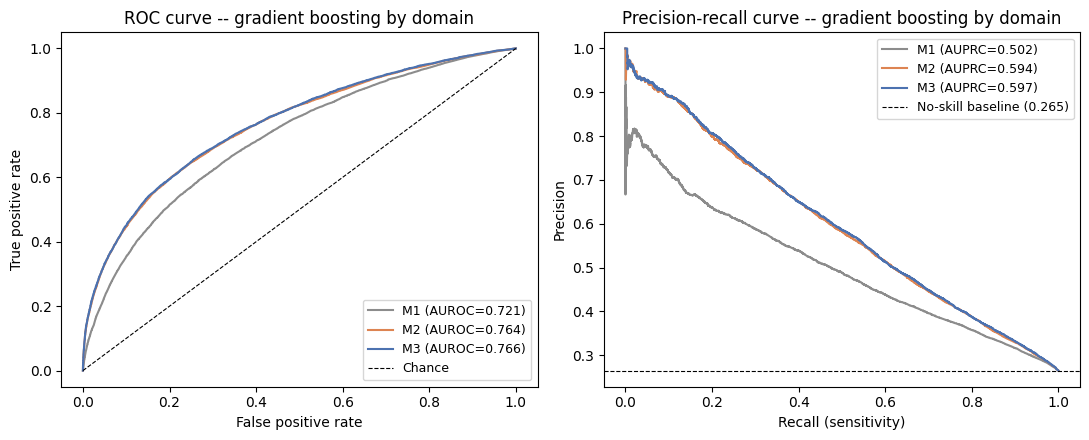

In [6]:
from sklearn.metrics import roc_curve, precision_recall_curve

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
colors = {"M1": "#8C8C8C", "M2": "#DD8452", "M3": "#4C72B0"}

for domain_name in ["M1", "M2", "M3"]:
    proba = gb_test_probas[domain_name]
    fpr, tpr, _ = roc_curve(y_test, proba)
    auroc = roc_auc_score(y_test, proba)
    axes[0].plot(fpr, tpr, color=colors[domain_name], label=f"{domain_name} (AUROC={auroc:.3f})")

    precision, recall, _ = precision_recall_curve(y_test, proba)
    auprc = average_precision_score(y_test, proba)
    axes[1].plot(recall, precision, color=colors[domain_name], label=f"{domain_name} (AUPRC={auprc:.3f})")

axes[0].plot([0, 1], [0, 1], linestyle="--", color="black", linewidth=0.8, label="Chance")
axes[0].set_xlabel("False positive rate")
axes[0].set_ylabel("True positive rate")
axes[0].set_title("ROC curve -- gradient boosting by domain")
axes[0].legend(loc="lower right", fontsize=9)

axes[1].axhline(y_test.mean(), linestyle="--", color="black", linewidth=0.8,
                label=f"No-skill baseline ({y_test.mean():.3f})")
axes[1].set_xlabel("Recall (sensitivity)")
axes[1].set_ylabel("Precision")
axes[1].set_title("Precision-recall curve -- gradient boosting by domain")
axes[1].legend(loc="upper right", fontsize=9)

plt.tight_layout()
plt.savefig(FIGURES_DIR / "fig15_gb_roc_pr_curves.png", dpi=150)
plt.show()

## Analysis of factors

Like Random Forest, `HistGradientBoostingClassifier` has no coefficients, so the same
permutation-importance approach is used here for comparability -- shuffle one predictor at a
time in the held-out test data and measure the drop in AUROC, computed on the fitted M3 pipeline
on a random 15,000-row test subsample with 5 repeats per feature.

In [7]:
from sklearn.inspection import permutation_importance

gb_m3_pipeline = MODEL_REGISTRY["gb_M3"]["pipeline"]

rng = np.random.RandomState(RANDOM_SEED)
perm_sample_idx = rng.choice(X_test.index, size=15_000, replace=False)

perm_result = permutation_importance(
    gb_m3_pipeline, X_test.loc[perm_sample_idx, M3_FEATURES], y_test.loc[perm_sample_idx],
    n_repeats=5, random_state=RANDOM_SEED, scoring="roc_auc", n_jobs=1,  # n_jobs=1, not -1: permutation_importance with multiprocessing pickles the whole fitted pipeline + data per worker, which has been reported to raise a MemoryError/PicklingError on some Windows setups (joblib's loky backend) -- single-process is slower but reliable everywhere.
)

gb_perm_importance_table = pd.DataFrame({
    "feature": M3_FEATURES,
    "importance_mean": perm_result.importances_mean,
    "importance_std": perm_result.importances_std,
}).sort_values("importance_mean", ascending=False)
gb_perm_importance_table.to_csv(MODEL_DIR / "gb_permutation_importance.csv", index=False)
gb_perm_importance_table.round(4)

,feature,importance_mean,importance_std
0,age_group,0.0767,0.0029
11,checkup_recency,0.0416,0.0008
4,income_group,0.0103,0.0005
9,personal_doctor,0.0084,0.0008
3,education_level,0.0083,0.0014
5,employment_status,0.0071,0.0012
6,marital_status,0.0054,0.0002
15,smoking_status,0.0035,0.0003
2,race_ethnicity,0.0035,0.0003
8,insurance_status,0.0033,0.0010


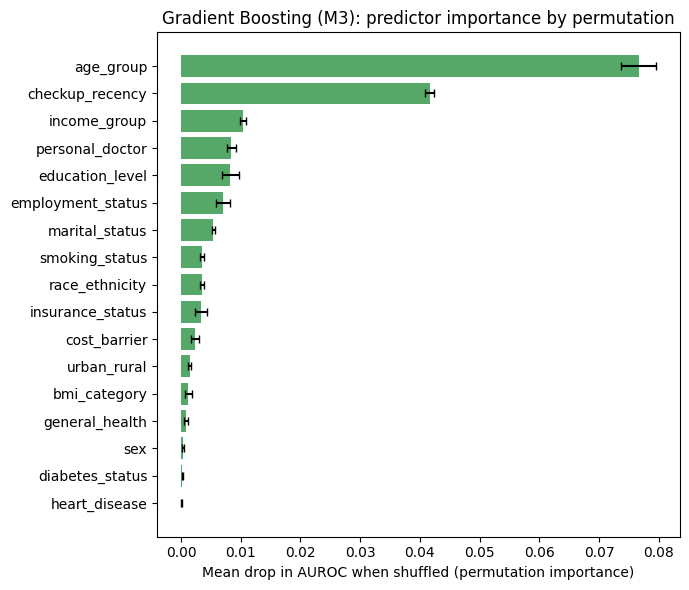

In [8]:
fig, ax = plt.subplots(figsize=(7, 6))
plot_order = gb_perm_importance_table.sort_values("importance_mean")
ax.barh(
    plot_order["feature"], plot_order["importance_mean"],
    xerr=plot_order["importance_std"], color="#55A868", capsize=3,
)
ax.set_xlabel("Mean drop in AUROC when shuffled (permutation importance)")
ax.set_title("Gradient Boosting (M3): predictor importance by permutation")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "fig16_gb_permutation_importance.png", dpi=150)
plt.show()

**Reading the chart:** the ranking is essentially the same as Random Forest's -- `age_group`
dominates (mean AUROC drop ~0.077), `checkup_recency` a clear second (~0.042), then a steep
drop-off. The two tree-based models agree with each other far more than either agrees with the
logistic regression odds ratios on relative magnitude, which is expected: both exploit the same
non-linear age gradient that a single linear coefficient can't fully capture (see the Random
Forest discussion above). `income_group` and `education_level` place slightly higher here than in
the Random Forest ranking, but the overall story -- age and recent-checkup history as the two
dominant signals, with access variables as a consistent secondary tier -- holds across both tree
models.

### Hyperparameter search

Same approach as Random Forest's search above: `RandomizedSearchCV` on a 40,000-row training
subsample (not the full 136,588 rows, purely for runtime), 3-fold stratified CV, 10 parameter
combinations, scored on AUROC. Search space covers the parameters that matter most for
`HistGradientBoostingClassifier`: `learning_rate` and `max_iter` trade off boosting speed against
number of rounds, `max_leaf_nodes` and `max_depth` control tree complexity, `min_samples_leaf` and
`l2_regularization` control overfitting directly. Done within the training fold only, consistent
with the calibration-vs-validation distinction from notebook 3 -- the calibration and test splits
are untouched by this search.

In [9]:
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold

search_sample_idx = np.random.RandomState(RANDOM_SEED).choice(X_train.index, size=40_000, replace=False)
X_search = X_train.loc[search_sample_idx, M3_FEATURES]
y_search = y_train.loc[search_sample_idx]
w_search = compute_sample_weight("balanced", y_search)

gb_search_pipe = build_gb_pipeline(M3_FEATURES)
gb_param_distributions = {
    "model__learning_rate": [0.01, 0.05, 0.1, 0.2],
    "model__max_iter": [100, 200, 300],
    "model__max_leaf_nodes": [15, 31, 63, 127],
    "model__max_depth": [None, 5, 10, 15],
    "model__min_samples_leaf": [10, 20, 50, 100],
    "model__l2_regularization": [0.0, 0.1, 1.0],
}

gb_search = RandomizedSearchCV(
    gb_search_pipe, gb_param_distributions, n_iter=10,
    cv=StratifiedKFold(3, shuffle=True, random_state=RANDOM_SEED),
    scoring="roc_auc", random_state=RANDOM_SEED, n_jobs=1,
)
gb_search.fit(X_search, y_search, model__sample_weight=w_search)

print("Best parameters found:", gb_search.best_params_)
print(f"Best CV AUROC (on the 40k search subsample): {gb_search.best_score_:.4f}")

Best parameters found: {'model__min_samples_leaf': 50, 'model__max_leaf_nodes': 15, 'model__max_iter': 300, 'model__max_depth': 5, 'model__learning_rate': 0.1, 'model__l2_regularization': 0.0}
Best CV AUROC (on the 40k search subsample): 0.7615


In [10]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OrdinalEncoder
from sklearn.ensemble import HistGradientBoostingClassifier

best_gb_params = {
    k.replace("model__", ""): v for k, v in gb_search.best_params_.items()
}

gb_tuned_pipe = Pipeline([
    ("preprocess", ColumnTransformer([
        ("cat", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1), M3_FEATURES),
    ])),
    ("model", HistGradientBoostingClassifier(
        categorical_features=[True] * len(M3_FEATURES), random_state=RANDOM_SEED, **best_gb_params,
    )),
])
gb_tuned_pipe.fit(X_train[M3_FEATURES], y_train, model__sample_weight=w_train)

proba_gb_tuned = gb_tuned_pipe.predict_proba(X_test[M3_FEATURES])[:, 1]
gb_tuned_metrics = compute_classification_metrics(y_test, proba_gb_tuned)

register_model(
    name="gb_M3_tuned", pipeline=gb_tuned_pipe, metrics=gb_tuned_metrics, features=M3_FEATURES,
    model_type="Gradient Boosting (class-weighted, RandomizedSearchCV-tuned)",
    notes=(f"{best_gb_params} -- from a 10-iter/cv=3 RandomizedSearchCV on a 40k-row training subsample."),
)

gb_comparison = pd.DataFrame([
    {"Model": "gb_M3 (defaults)", **MODEL_REGISTRY["gb_M3"]["metrics"]},
    {"Model": "gb_M3_tuned (searched)", **gb_tuned_metrics},
])
gb_comparison.round(4)

,Model,AUROC,AUPRC,Precision,Sensitivity,Specificity,F1,Accuracy
0,gb_M3 (defaults),0.7659,0.5970,0.4888,0.6364,0.7603,0.5529,0.7275
1,gb_M3_tuned (searched),0.7662,0.5974,0.4910,0.6385,0.7617,0.5551,0.7291


**Reading this comparison:** the search landed on `min_samples_leaf=50`, shallow trees
(`max_depth=5`, `max_leaf_nodes=15`), `max_iter=300`, the default `learning_rate=0.1`, and no
extra `l2_regularization` -- shallower, more constrained trees than the library default (which
places no cap on `max_depth`), run for more boosting rounds to compensate. The tuned model gets
test AUROC 0.7662 vs. 0.7659 for the untuned default -- essentially a tie, the same "tuning within
a family barely moves the needle" pattern seen with Random Forest (0.7620 vs. 0.7613). Both
gradient boosting variants still comfortably lead the comparison. `gb_M3_tuned` is registered
alongside everything else and included in the model comparison below.